# Логичтическая регрессия, метод опорных векторов, one-hot кодирование

### О задании

В этом задании вы изучите методы работы с категориальными переменными

In [1]:
%pylab inline
import pandas as pd

from sklearn.base import BaseEstimator
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


__Задание 1.__ Обучение логистической регрессии на реальных данных и оценка качества классификации.

**(2 балла)**


Загрузим данные с конкурса [Kaggle Porto Seguro's Safe Driver Prediction](https://www.kaggle.com/c/porto-seguro-safe-driver-prediction) (вам нужна только обучающая выборка). Задача состоит в определении водителей, которые в ближайший год воспользуются своей автомобильной страховкой (бинарная классификация). Но для нас важна будет не сама задача, а только её данные. При этом под нужды задания мы немного модифицируем датасет.

In [2]:
import pandas as pd
data = pd.read_csv('train.csv', index_col=0)
target = data.target.values
data = data.drop('target', axis=1)

Пересемплируем выборку так, чтобы положительных и отрицательных объектов в выборке было одинаковое число. Разделим на обучающую и тестовую выборки.

In [3]:
from sklearn.model_selection import train_test_split
np.random.seed(910)
maskPlus = np.random.choice(np.where(target == 1)[0], 100000, replace=True)
maskZero = np.random.choice(np.where(target == 0)[0], 100000, replace=True)

data = pd.concat((data.iloc[maskPlus], data.iloc[maskZero]))
target = np.hstack((target[maskPlus], target[maskZero]))

xTrain, xTest, yTrain, yTest = train_test_split(data, target, test_size=0.5)

Не забудьте отнормировать признаки (можно воспользоваться StandardScaler или сделать это вручную). Пока не будем обращать внимание на то, что некоторые признаки категориальные (этим мы займёмся позже).

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, log_loss
import time

scaler = StandardScaler()

#Выберем только числовые колонки и заполним пустоты медианой и пропуски пустотой
catCols = [col for col in data.columns if 'cat' in col]
binCols = [col for col in data.columns if 'bin' in col]
numericCols = [col for col in data.columns if col not in catCols + binCols]

xTrain_1 = xTrain[numericCols].copy()
xTest_1 = xTest[numericCols].copy()

xTrain_1 = xTrain_1.replace(-1, np.nan)
xTest_1 = xTest_1.replace(-1, np.nan)

xTrain_1 = xTrain_1.fillna(xTrain_1.median())
xTest_1 = xTest_1.fillna(xTrain_1.median())

xTrain_1= scaler.fit_transform(xTrain_1)
xTest_1 = scaler.transform(xTest_1)

Обучите логистическую регрессию с удобными для вас параметрами, примените регуляризацию, найдтие оптимум. Сделайте предсказание на тестовой части выборки. Замерьте качество.

In [5]:
from sklearn.model_selection import GridSearchCV

#Находим через GridSearchCV параметры для поиска оптимума
paramGrid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'], 
    'solver': ['liblinear'] #Работает с обеими регуляризациями
}

gridSearch = GridSearchCV(LogisticRegression(max_iter=1000), paramGrid, cv=3, n_jobs=-1, verbose=1)
gridSearch.fit(xTrain_1, yTrain)
bestLogReg = gridSearch.best_estimator_

#Обучаем
yPredOptimum = bestLogReg.predict(xTest_1)
yPredProbaOptimum = bestLogReg.predict_proba(xTest_1)[:, 1]
accuracyOptimum = accuracy_score(yTest, yPredOptimum)

print(classification_report(yTest, yPredOptimum))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
              precision    recall  f1-score   support

           0       0.56      0.61      0.59     49994
           1       0.58      0.53      0.55     50006

    accuracy                           0.57    100000
   macro avg       0.57      0.57      0.57    100000
weighted avg       0.57      0.57      0.57    100000



__Выводы__ в свободной форме:

__Задание 2.__ Изучение влияния регуляризатора на процесс обучения

__(2 балла)__

Проверьте на практике, как влияет регуляризатор на процесс обучения (убывание функции потерь на обучающей и отложенной выборках). Чтобы считать функцию потерь на отложенной выборке после каждой итерации, запускайте процесс обучения логистической регрессии с параметром $max\_iter=1$ и $w^{(0)}$, полученным на предыдущей итерации. Постройте два графика: на одном из них логистическая регрессия с коэффициентом регуляризации, равным 0, а на другом с некоторым разумным значением. На каждом графике одновременно должна быть и функция потерь для обучающей, и для тестовой выборки. Не забудьте сделать одинаковыми оси обоих графиков. Какие выводы вы можете сделать?

Iteration 0: Train Loss = 0.6799, Test Loss = 0.6806


Iteration 10: Train Loss = 0.6776, Test Loss = 0.6780


Iteration 20: Train Loss = 0.6776, Test Loss = 0.6780


Iteration 30: Train Loss = 0.6776, Test Loss = 0.6780


Iteration 40: Train Loss = 0.6776, Test Loss = 0.6780
Iteration 50: Train Loss = 0.6776, Test Loss = 0.6780
Iteration 60: Train Loss = 0.6776, Test Loss = 0.6780
Iteration 70: Train Loss = 0.6776, Test Loss = 0.6780
Iteration 80: Train Loss = 0.6776, Test Loss = 0.6780
Iteration 90: Train Loss = 0.6776, Test Loss = 0.6780


...

Iteration 40: Train Loss = 0.6776, Test Loss = 0.6780
Iteration 50: Train Loss = 0.6776, Test Loss = 0.6780
Iteration 60: Train Loss = 0.6776, Test Loss = 0.6780
Iteration 70: Train Loss = 0.6776, Test Loss = 0.6780
Iteration 80: Train Loss = 0.6776, Test Loss = 0.6780
Iteration 90: Train Loss = 0.6776, Test Loss = 0.6780


Iteration 0: Train Loss = 0.6802, Test Loss = 0.6808


Iteration 10: Train Loss = 0.6785, Test Loss = 0.6790


Iteration 20: Train Loss = 0.6785, Test Loss = 0.6790


Iteration 30: Train Loss = 0.6785, Test Loss = 0.6790
Iteration 40: Train Loss = 0.6785, Test Loss = 0.6790
Iteration 50: Train Loss = 0.6785, Test Loss = 0.6790
Iteration 60: Train Loss = 0.6785, Test Loss = 0.6790
Iteration 70: Train Loss = 0.6785, Test Loss = 0.6790
Iteration 80: Train Loss = 0.6785, Test Loss = 0.6790
Iteration 90: Train Loss = 0.6785, Test Loss = 0.6790


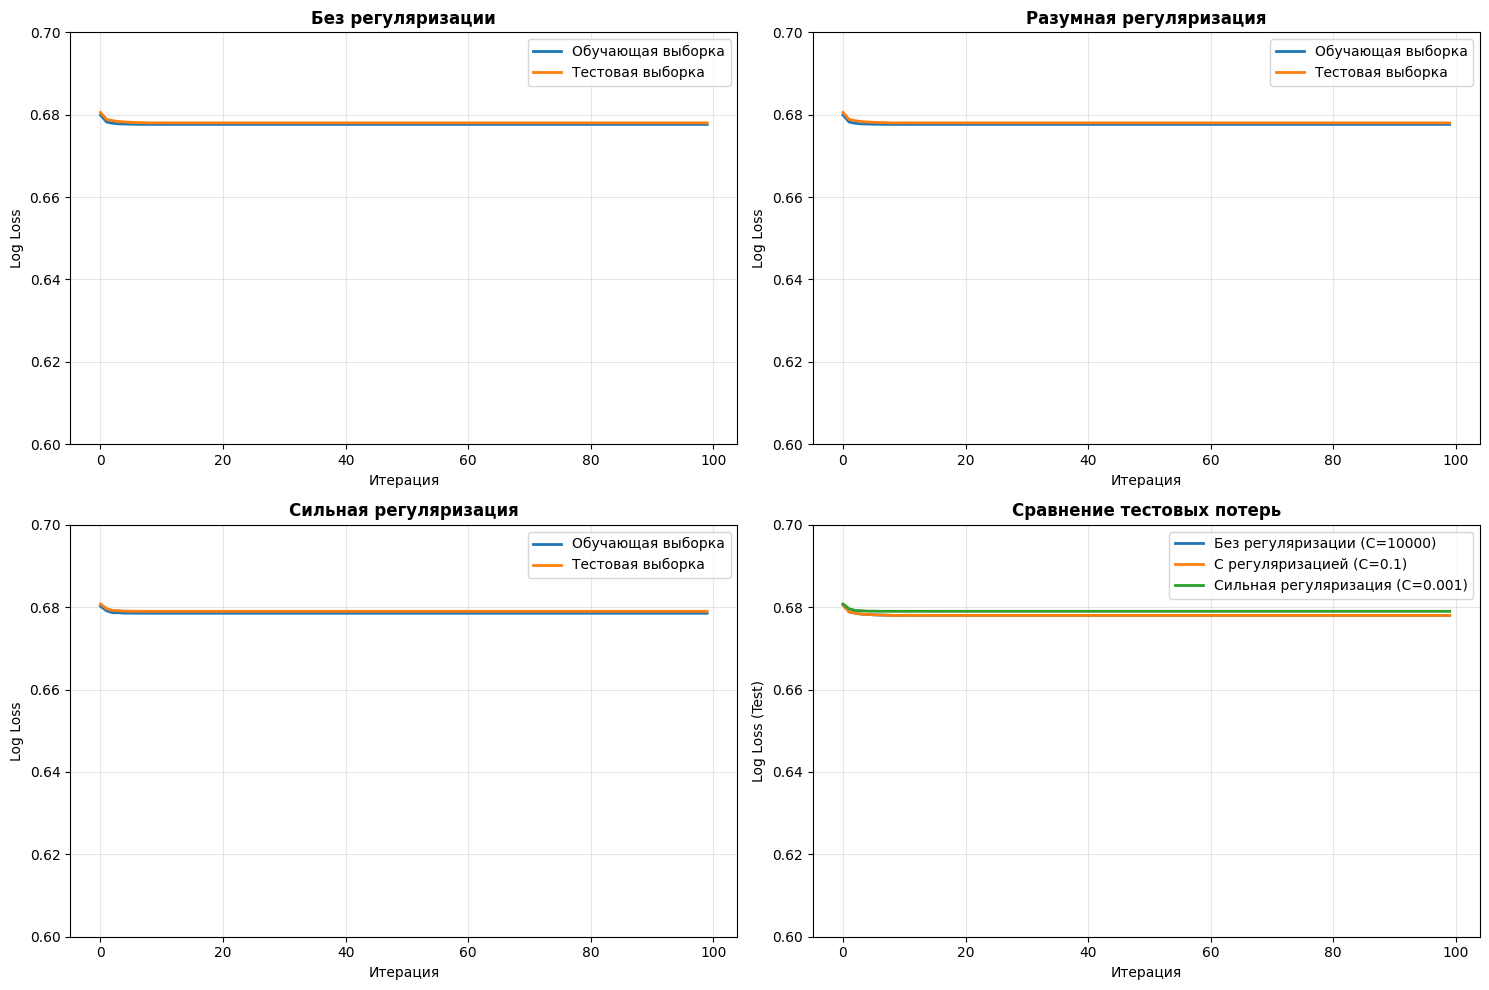

In [6]:
import matplotlib.pyplot as plt

#Функция для обучения с отслеживанием потерь на каждой итерации
def trainLogisticRegressionWithTracking(c, xTrain, xTest, yTrain, yTest, max_iter=100):
    trainLosses = []
    testLosses = []

    model = LogisticRegression(
        C=c, 
        max_iter=1,  #Обучаем по одной итерации за раз
        warm_start=True,  #Сохраняем веса между итерациями
        tol=1e-8
    )
    
    #Постепенное обучение с сохранением истории потерь
    for i in range(max_iter):
        model.fit(xTrain, yTrain)
        
        yTrain_proba = model.predict_proba(xTrain)
        yTest_proba = model.predict_proba(xTest)
        
        trainLoss = log_loss(yTrain, yTrain_proba)
        testLoss = log_loss(yTest, yTest_proba)
        trainLosses.append(trainLoss)
        
        testLosses.append(testLoss)

        if i % 10 == 0:
            print(f"Iteration {i}: Train Loss = {trainLoss:.4f}, Test Loss = {testLoss:.4f}")
    
    return trainLosses, testLosses, model

#Без регуляризации, C большое
trainLoss_noReg, testLoss_noReg, model_noReg = trainLogisticRegressionWithTracking(
    c=1000000, 
    xTrain=xTrain_1, 
    xTest=xTest_1, 
    yTrain=yTrain, 
    yTest=yTest,
    max_iter=100
)

#Разумная регуляризация
trainLoss_withReg, testLoss_withReg, model_withReg = trainLogisticRegressionWithTracking(
    c=0.1, 
    xTrain=xTrain_1, 
    xTest=xTest_1, 
    yTrain=yTrain, 
    yTest=yTest,
    max_iter=100
)

#Сильная регуляризация
trainLoss_strongReg, testLoss_strongReg, model_strongReg = trainLogisticRegressionWithTracking(
    c=0.0001, 
    xTrain=xTrain_1, 
    xTest=xTest_1, 
    yTrain=yTrain, 
    yTest=yTest,
    max_iter=100
)

#Графики
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(trainLoss_noReg, label='Обучающая выборка', linewidth=2)
plt.plot(testLoss_noReg, label='Тестовая выборка', linewidth=2)
plt.title('Без регуляризации', fontsize=12, fontweight='bold')
plt.xlabel('Итерация')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.6, 0.7)  #Фиксируем масштаб для сравнения

plt.subplot(2, 2, 2)
plt.plot(trainLoss_withReg, label='Обучающая выборка', linewidth=2)
plt.plot(testLoss_withReg, label='Тестовая выборка', linewidth=2)
plt.title('Разумная регуляризация', fontsize=12, fontweight='bold')
plt.xlabel('Итерация')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.6, 0.7)

plt.subplot(2, 2, 3)
plt.plot(trainLoss_strongReg, label='Обучающая выборка', linewidth=2)
plt.plot(testLoss_strongReg, label='Тестовая выборка', linewidth=2)
plt.title('Сильная регуляризация', fontsize=12, fontweight='bold')
plt.xlabel('Итерация')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.6, 0.7)

plt.subplot(2, 2, 4)
plt.plot(testLoss_noReg, label='Без регуляризации (C=10000)', linewidth=2)
plt.plot(testLoss_withReg, label='С регуляризацией (C=0.1)', linewidth=2)
plt.plot(testLoss_strongReg, label='Сильная регуляризация (C=0.001)', linewidth=2)
plt.title('Сравнение тестовых потерь', fontsize=12, fontweight='bold')
plt.xlabel('Итерация')
plt.ylabel('Log Loss (Test)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.6, 0.7)

plt.tight_layout()
plt.show()

__Выводы:__

Модель очень быстро сходится почти независимо от регуляризации.

Написал ли я криво или датасет такой - без понятия.

## Часть 2. Работа с категориальными переменными

В этой части мы научимся обрабатывать категориальные переменные, так как закодировать их в виде чисел недостаточно (это задаёт некоторый порядок, которого на категориальных переменных может и не быть). Существует два основных способа обработки категориальных значений:
- One-hot-кодирование
- Счётчики (CTR, mean-target кодирование, ...) — каждый категориальный признак заменяется на среднее значение целевой переменной по всем объектам, имеющим одинаковое значение в этом признаке.

Начнём с one-hot-кодирования. Допустим наш категориальный признак $f_j(x)$ принимает значения из множества $C=\{c_1, \dots, c_m\}$. Заменим его на $m$ бинарных признаков $b_1(x), \dots, b_m(x)$, каждый из которых является индикатором одного из возможных категориальных значений:
$$
b_i(x) = [f_j(x) = c_i]
$$

__Задание 1.__ Закодируйте все категориальные признаки с помощью one-hot-кодирования. Обучите логистическую регрессию и посмотрите, как изменилось качество модели (с тем, что было ранее). Измерьте время, потребовавшееся на обучение модели.

__(3 балла)__

In [7]:
# Your code here
# ...

Как можно было заменить, one-hot-кодирование может сильно увеличивать количество признаков в датасете, что сказывается на памяти, особенно, если некоторый признак имеет большое количество значений. Эту проблему решает другой способ кодирование категориальных признаков — счётчики. Основная идея в том, что нам важны не сами категории, а значения целевой переменной, которые имеют объекты этой категории. Каждый категориальный признак мы заменим средним значением целевой переменной по всем объектам этой же категории:
$$
g_j(x, X) = \frac{\sum_{i=1}^{l} [f_j(x) = f_j(x_i)][y_i = +1]}{\sum_{i=1}^{l} [f_j(x) = f_j(x_i)]}
$$

__Задание 2.__ Закодируйте категориальные переменные с помощью счётчиков (ровно так, как описано выше без каких-либо хитростей). Обучите логистическую регрессию и посмотрите на качество модели на тестовом множестве. Сравните время обучения с предыдущим экспериментов. Заметили ли вы что-то интересное?

__(2 балла)__

In [8]:
# Your code here
# ...

__Вывод:__

Отметим, что такие признаки сами по себе являются классификаторами и, обучаясь на них, мы допускаем "утечку" целевой переменной в признаки. Это ведёт к переобучению, поэтому считать такие признаки необходимо таким образом, чтобы при вычислении для конкретного объекта его целевая метка не использовалась. Это можно делать следующими способами:
- вычислять значение счётчика по всем объектам расположенным выше в датасете (например, если у нас выборка отсортирована по времени)
- вычислять по фолдам, то есть делить выборку на некоторое количество частей и подсчитывать значение признаков по всем фолдам кроме текущего (как делается в кросс-валидации)
- внесение некоторого шума в посчитанные признаки (необходимо соблюсти баланс между избавление от переобучения и полезностью признаков).

__Задание 3.__ Реализуйте корректное вычисление счётчиков двумя из трех вышеперчисленных способов, сравните. Снова обучите логистическую регрессию, оцените качество. Сделайте выводы.

__(3 балла)__

In [9]:
# Your code here
# ...

__Вывод:__